# DE — Clasificación con Random Forest

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 5. Clasificación (DE) sobre breast-cancer.csv

Implementar un algoritmo de clasificación alterno al usado en SA (k-NN): un Bosque Aleatorio (Random Forest) sobre breast-cancer.csv, con evaluación y optimización de hiperparámetros.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **Random Forest** como algoritmo alterno al k-NN usado en SA. Es un método de ensamble (bagging de árboles de decisión) que reduce la varianza del sobreajuste, maneja bien datos tabulares con muchas características (30 aquí) y no requiere escalado. Es uno de los algoritmos de clasificación más robustos y de los vistos en clase; además permite medir la importancia de las características.

In [2]:
df = pd.read_csv(os.path.join(DATA, "breast-cancer.csv"))
X = df.drop(columns=["id", "diagnosis"])
y = df["diagnosis"].map({"M": 1, "B": 0})
print("Dimensiones:", X.shape, "| Clases:", y.value_counts().to_dict())

Dimensiones: (569, 30) | Clases: {0: 357, 1: 212}


## Diseño del modelo (paso a paso)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Entrenamiento:", X_train.shape[0], "| Prueba:", X_test.shape[0])

Entrenamiento: 426 | Prueba: 143


## Evaluación y optimización — búsqueda de hiperparámetros

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipe = RandomForestClassifier(random_state=42)
grid = {"n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5]}
gs = GridSearchCV(pipe, grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(X_train, y_train)
print("Mejores hiperparámetros:", gs.best_params_)
print("Mejor accuracy (CV):", round(gs.best_score_, 4))

Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mejor accuracy (CV): 0.9648


### Evaluación del modelo óptimo en prueba

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

modelo = gs.best_estimator_
y_pred = modelo.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("\n", classification_report(y_test, y_pred, target_names=["Benigno", "Maligno"]))

Accuracy : 0.965
Precision: 1.0
Recall   : 0.9057
F1       : 0.9505

               precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        90
     Maligno       1.00      0.91      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.95      0.96       143
weighted avg       0.97      0.97      0.96       143



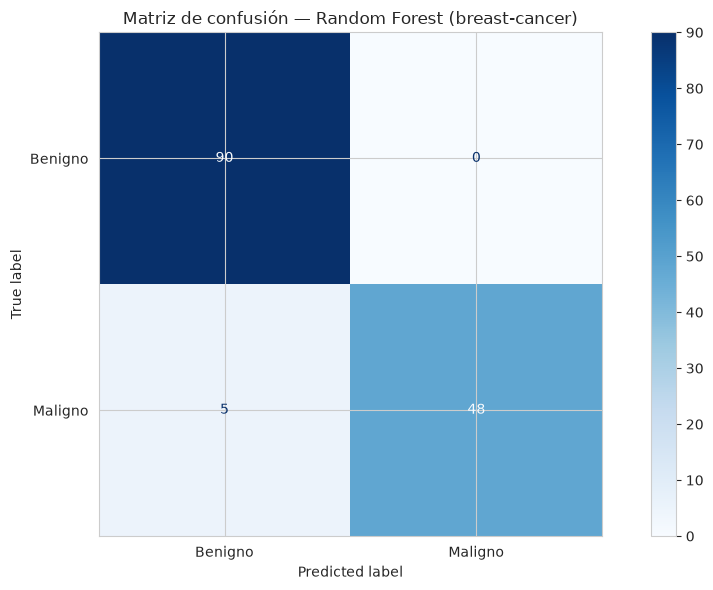

In [6]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Benigno", "Maligno"]).plot(cmap="Blues")
plt.title("Matriz de confusión — Random Forest (breast-cancer)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "confusion_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

### Importancia de las características

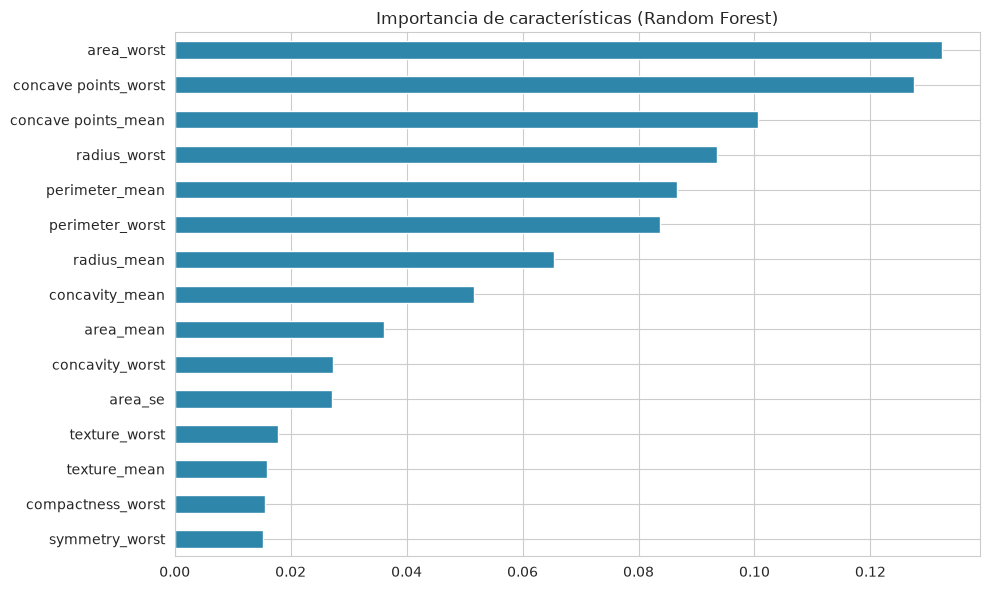

In [7]:
imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
imp.plot(kind="barh", color="#2E86AB")
plt.title("Importancia de características (Random Forest)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "importancia_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

### Graficar un árbol del bosque

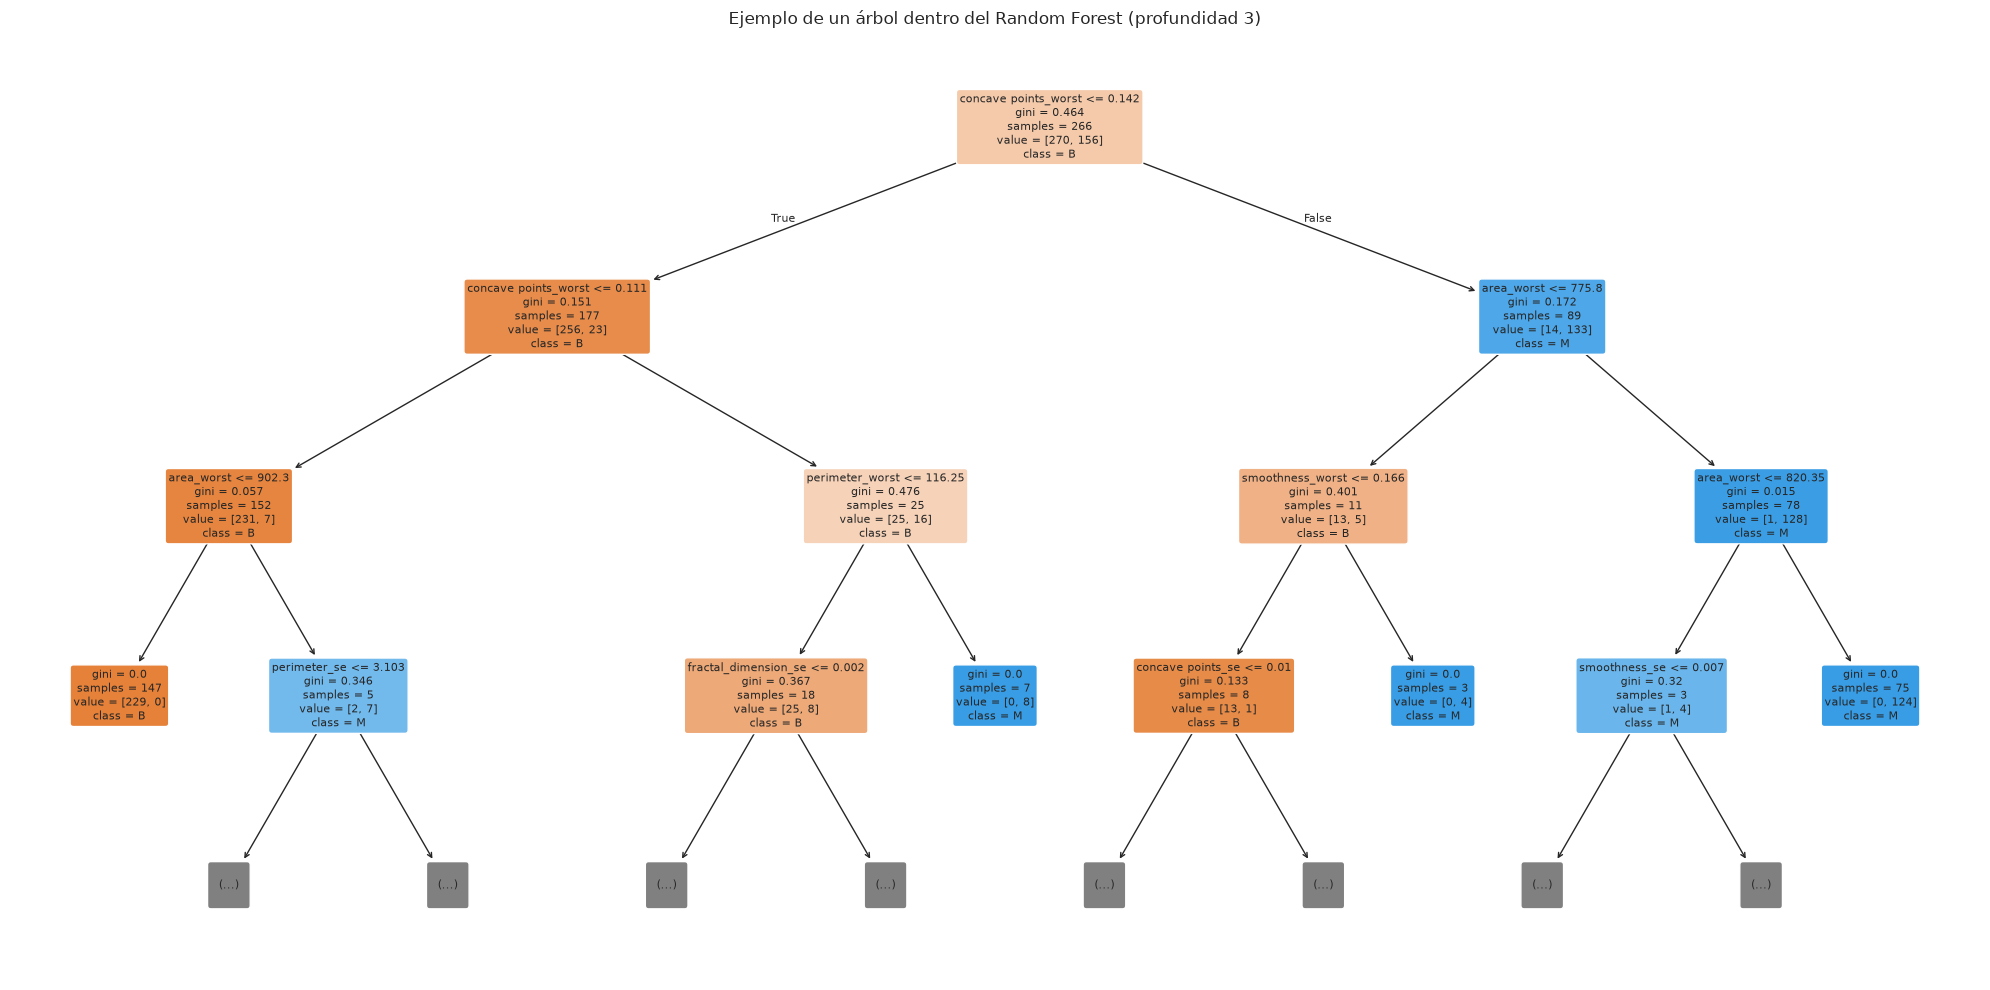

In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelo.estimators_[0], feature_names=X.columns, class_names=["B", "M"],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.title("Ejemplo de un árbol dentro del Random Forest (profundidad 3)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "arbol_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

## Guardar el modelo

In [9]:
import joblib
joblib.dump(modelo, os.path.join(MODELOS, "breast_randomforest.pkl"))
print("Modelo guardado en modelos/breast_randomforest.pkl")

Modelo guardado en modelos/breast_randomforest.pkl


## Verificación de integridad (recarga del modelo)

In [10]:
modelo_cargado = joblib.load(os.path.join(MODELOS, "breast_randomforest.pkl"))
y_verif = modelo_cargado.predict(X_test)
print("Accuracy tras recargar:", round(accuracy_score(y_test, y_verif), 4))
print("Coincide:", np.array_equal(y_verif, y_pred))

Accuracy tras recargar: 0.965
Coincide: True
